In [1]:
import sys
from pathlib import Path


NOTEBOOK_DIR = Path().resolve()
TRAIN_DIR = NOTEBOOK_DIR / "train"
MODELS_DIR = NOTEBOOK_DIR / "models"
if str(TRAIN_DIR) not in sys.path:
    sys.path.append(str(TRAIN_DIR))
if str(MODELS_DIR) not in sys.path:
    sys.path.append(str(MODELS_DIR))

from dataset_spacenet import SpaceNetDataset
from hrnet_w48_sn7 import HRNetW48

Total patches in split 'test': 10246
Evaluating test patch index: 8620


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


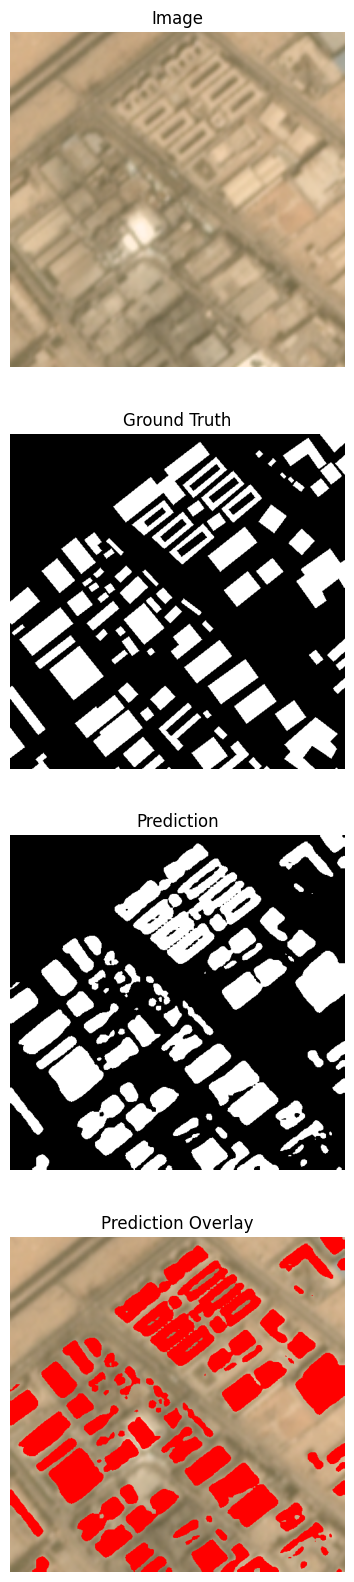

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import random
from pathlib import Path

from dataset_spacenet import SpaceNetDataset
from hrnet_w48_sn7 import HRNetW48




device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = HRNetW48(in_channels=4, num_classes=2)


NOTEBOOK_DIR = Path().resolve()

ckpt_path = NOTEBOOK_DIR / "train" / "weights" / "weights_69.pth"  # Update epoch number here (e.g. weights_69.pth)

if not ckpt_path.exists():
    raise FileNotFoundError(
        f"Checkpoint not found at {ckpt_path}.\n"
        "Either train a model with train/train_hrnet_sn7.py "
        "(it will save to train/checkpoints/latest.pth), or update ckpt_path "
        "to point to an existing .pth file."
    )

weights = torch.load(ckpt_path, map_location=device)

model.load_state_dict(weights)
model.to(device)
model.eval()



root = NOTEBOOK_DIR / "data" / "SN7_buildings_train" / "train"

SPLIT_DIR = NOTEBOOK_DIR / "splits"

dataset = SpaceNetDataset(str(root), split="test", split_list_dir=str(SPLIT_DIR))


random.seed()
idx = random.randint(0, len(dataset) - 1)
print(f"Evaluating test patch index: {idx}")
image, mask = dataset[idx]

image_t = image.unsqueeze(0).to(device)

with torch.no_grad():

    pred = model(image_t)

    pred = torch.nn.functional.interpolate(
        pred,
        size=(512,512),
        mode="bilinear",
        align_corners=False
    )

    pred = torch.softmax(pred, dim=1)
    pred = pred.argmax(1).cpu().numpy()[0]


image_np = image.numpy().transpose(1,2,0)
mask_np = mask.numpy()



fig, axes = plt.subplots(4,1,figsize=(10,20))

axes[0].imshow(image_np[:,:,:3])
axes[0].set_title("Image")

axes[1].imshow(mask_np, cmap="gray")
axes[1].set_title("Ground Truth")

axes[2].imshow(pred, cmap="gray")
axes[2].set_title("Prediction")

overlay = image_np[:,:,:3].copy()
overlay[pred==1] = [255,0,0]

axes[3].imshow(overlay)
axes[3].set_title("Prediction Overlay")

for ax in axes:
    ax.axis("off")

plt.show()

Evaluating Full Image: global_monthly_2018_01_mosaic_L15-1672E-1207N_6691_3363_13.tif from L15-1672E-1207N_6691_3363_13


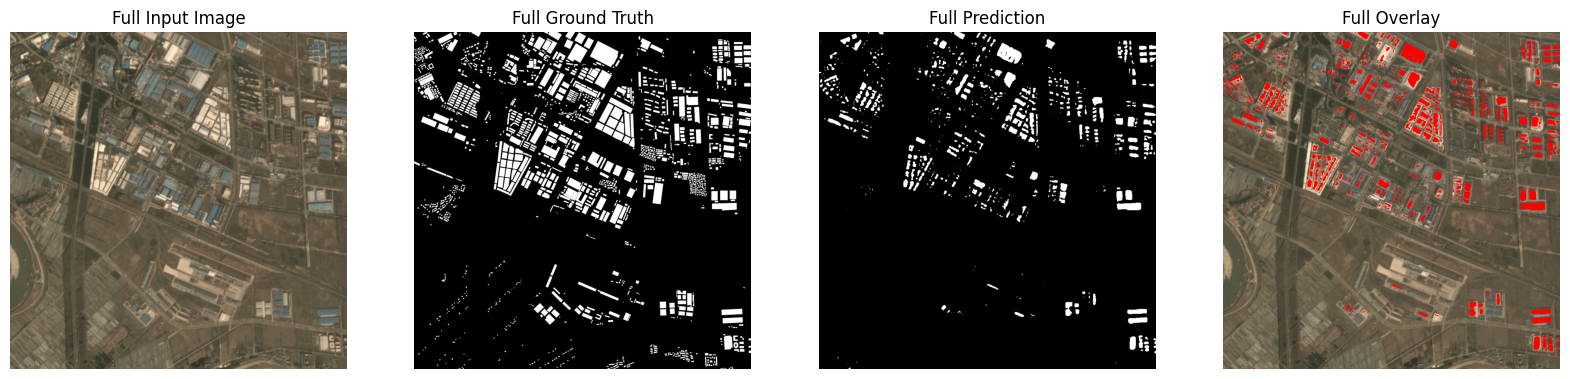

In [3]:

import os
import re
import random


idx = random.randint(0, len(dataset) - 1)
sample_patch = dataset.samples[idx][0] 

path_parts = sample_patch.split(os.sep)
aoi = path_parts[-3]
patch_filename = path_parts[-1]

orig_filename = re.sub(r"_\d{5}_\d{5}\.tif$", ".tif", patch_filename)

orig_img_path = os.path.join(root, aoi, "images_masked", orig_filename)
orig_mask_path = os.path.join(root, aoi, "masks_3x", orig_filename)

if not os.path.exists(orig_mask_path):
    print(f"Ground truth not found: {orig_mask_path}")
else:
    print(f"Evaluating Full Image: {orig_filename} from {aoi}")
    with rasterio.open(orig_img_path) as src:
        orig_image = src.read()[:4].astype(np.float32) / 255.0
    with rasterio.open(orig_mask_path) as src:
        orig_mask = src.read(1).astype(np.int64)

    image_t = torch.from_numpy(orig_image).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(image_t)
  
        pred = torch.nn.functional.interpolate(
            pred, size=(orig_image.shape[1], orig_image.shape[2]), mode="bilinear", align_corners=False
        )
        pred = torch.softmax(pred, dim=1).argmax(1).cpu().numpy()[0]

  
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    img_display = orig_image[:3].transpose(1, 2, 0)
    
    axes[0].imshow(img_display)
    axes[0].set_title("Full Input Image")
    
    axes[1].imshow(orig_mask, cmap="gray")
    axes[1].set_title("Full Ground Truth")

    axes[2].imshow(pred, cmap="gray")
    axes[2].set_title("Full Prediction")

    overlay = img_display.copy()
  
    overlay[pred == 1] = [1, 0, 0] 
    axes[3].imshow(overlay)
    axes[3].set_title("Full Overlay")

    for ax in axes: ax.axis("off")

    plt.show()

Random test image: L15-1672E-1207N_6691_3363_13/images_masked_3x_divide/global_monthly_2018_02_mosaic_L15-1672E-1207N_6691_3363_13_01024_02560.tif
Full path: /Users/aakashrajput/MachineLearning/spacenet/Final_sol/data/SN7_buildings_train/train/L15-1672E-1207N_6691_3363_13/images_masked_3x_divide/global_monthly_2018_02_mosaic_L15-1672E-1207N_6691_3363_13_01024_02560.tif
Image shape: (4, 512, 512)


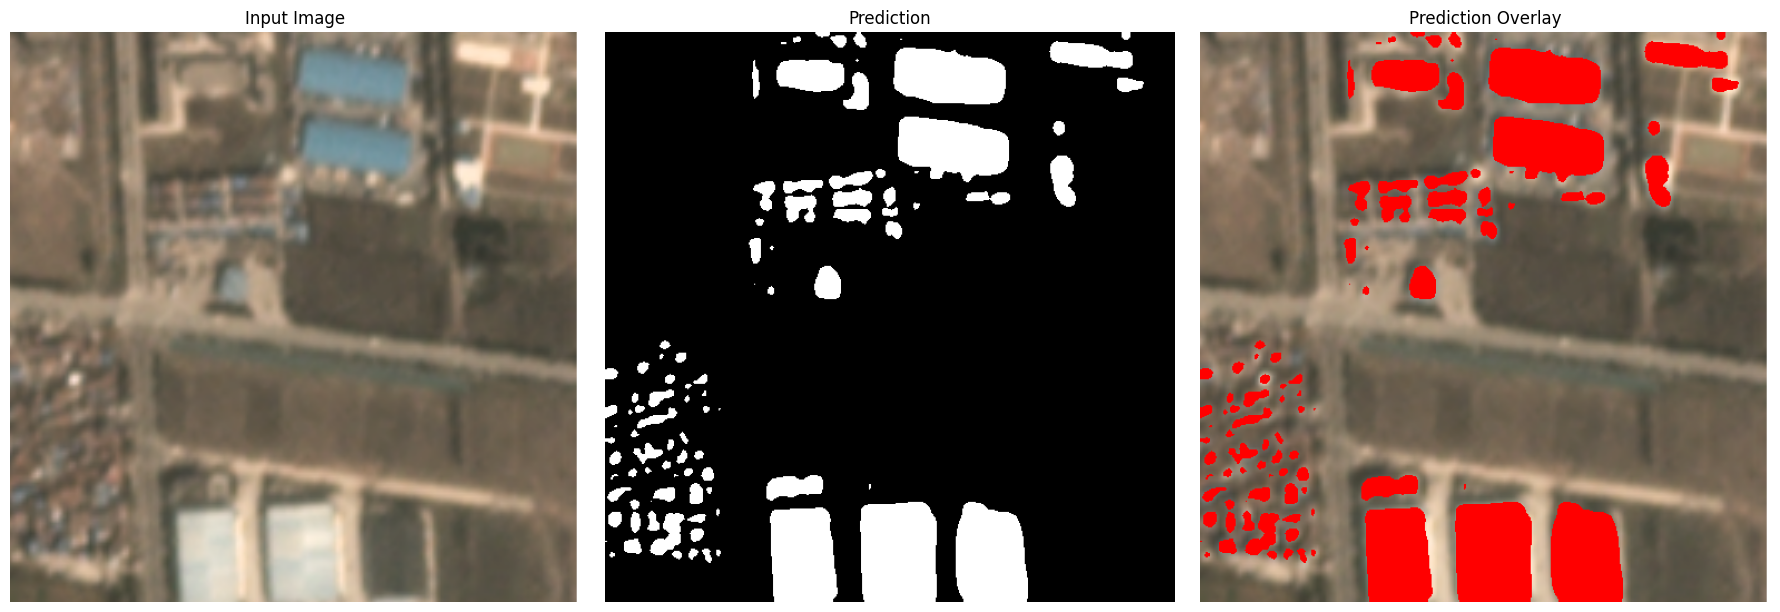

In [4]:
import os
import random
import torch
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import torch.nn.functional as F


# -----------------------------
# CONFIG
# -----------------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

# Assume model already loaded
model = model.to(device)
model.eval()


# -----------------------------
# PROJECT ROOT
# -----------------------------
project_root = os.getcwd()

test_list_path = os.path.join(project_root, "splits", "test_list.txt")


# -----------------------------
# READ TEST IMAGE LIST
# -----------------------------
with open(test_list_path, "r") as f:
    test_images = [line.strip().split()[0] for line in f if line.strip()]

if len(test_images) == 0:
    raise ValueError("test_list.txt is empty")


# -----------------------------
# PICK RANDOM TEST IMAGE
# -----------------------------
random_image_rel = random.choice(test_images)

print("Random test image:", random_image_rel)

image_path = os.path.join(project_root, "data", "SN7_buildings_train", "train", random_image_rel)

print("Full path:", image_path)


# -----------------------------
# LOAD IMAGE
# -----------------------------
with rasterio.open(image_path) as src:
    image = src.read()[:4].astype(np.float32) / 255.0


# Shape
C, H, W = image.shape

print("Image shape:", image.shape)


# -----------------------------
# CONVERT TO TORCH
# -----------------------------
image_tensor = torch.from_numpy(image).unsqueeze(0).to(device)


# -----------------------------
# MODEL INFERENCE
# -----------------------------
with torch.no_grad():

    pred = model(image_tensor)

    # Resize prediction to original resolution
    pred = F.interpolate(
        pred,
        size=(H, W),
        mode="bilinear",
        align_corners=False
    )

    pred = torch.softmax(pred, dim=1).argmax(1).cpu().numpy()[0]


# -----------------------------
# VISUALIZATION
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RGB image
rgb = image[:3].transpose(1, 2, 0)

axes[0].imshow(rgb)
axes[0].set_title("Input Image")

axes[1].imshow(pred, cmap="gray")
axes[1].set_title("Prediction")

# Overlay
overlay = rgb.copy()
overlay[pred == 1] = [1, 0, 0]

axes[2].imshow(overlay)
axes[2].set_title("Prediction Overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
import os
import re
import random
import torch
import rasterio
import numpy as np
import matplotlib.pyplot as plt


k = 10

save_dir = os.path.join(project_root, "samples_predictions", "chunks")
os.makedirs(save_dir, exist_ok=True)

for i in range(k):

    idx = random.randint(0, len(dataset) - 1)
    sample_patch = dataset.samples[idx][0]

    path_parts = sample_patch.split(os.sep)
    aoi = path_parts[-3]
    patch_filename = path_parts[-1]

    orig_filename = re.sub(r"_\d{5}_\d{5}\.tif$", ".tif", patch_filename)

    orig_img_path = os.path.join(root, aoi, "images_masked", orig_filename)
    orig_mask_path = os.path.join(root, aoi, "masks_3x", orig_filename)

    if not os.path.exists(orig_mask_path):
        print(f"Skipping (GT missing): {orig_mask_path}")
        continue

    print(f"Processing {i+1}/{k}: {orig_filename}")

    with rasterio.open(orig_img_path) as src:
        orig_image = src.read()[:4].astype(np.float32) / 255.0

    with rasterio.open(orig_mask_path) as src:
        orig_mask = src.read(1).astype(np.int64)

    image_t = torch.from_numpy(orig_image).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(image_t)

        pred = torch.nn.functional.interpolate(
            pred,
            size=(orig_image.shape[1], orig_image.shape[2]),
            mode="bilinear",
            align_corners=False
        )

        pred = torch.softmax(pred, dim=1).argmax(1).cpu().numpy()[0]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    img_display = orig_image[:3].transpose(1, 2, 0)

    axes[0].imshow(img_display)
    axes[0].set_title("Full Input Image")

    axes[1].imshow(orig_mask, cmap="gray")
    axes[1].set_title("Ground Truth")

    axes[2].imshow(pred, cmap="gray")
    axes[2].set_title("Prediction")

    overlay = img_display.copy()
    overlay[pred == 1] = [1, 0, 0]

    axes[3].imshow(overlay)
    axes[3].set_title("Overlay")

    for ax in axes:
        ax.axis("off")

    save_path = os.path.join(save_dir, f"prediction_{i}_{orig_filename}.png")
    plt.savefig(save_path, bbox_inches="tight")
    plt.close()

print(f"\nSaved {k} predictions to {save_dir}")

Processing 1/10: global_monthly_2019_06_mosaic_L15-1276E-1107N_5105_3761_13.tif
Processing 2/10: global_monthly_2019_09_mosaic_L15-1669E-1160N_6678_3548_13.tif
Processing 3/10: global_monthly_2018_03_mosaic_L15-1669E-1160N_6679_3549_13.tif
Processing 4/10: global_monthly_2019_05_mosaic_L15-1617E-1207N_6468_3360_13.tif
Processing 5/10: global_monthly_2018_06_mosaic_L15-1335E-1166N_5342_3524_13.tif
Processing 6/10: global_monthly_2020_01_mosaic_L15-1204E-1204N_4819_3372_13.tif
Processing 7/10: global_monthly_2018_03_mosaic_L15-1538E-1163N_6154_3539_13.tif
Processing 8/10: global_monthly_2018_10_mosaic_L15-1276E-1107N_5105_3761_13.tif
Processing 9/10: global_monthly_2019_03_mosaic_L15-0632E-0892N_2528_4620_13.tif
Processing 10/10: global_monthly_2018_07_mosaic_L15-0358E-1220N_1433_3310_13.tif

Saved 10 predictions to /Users/aakashrajput/MachineLearning/spacenet/Final_sol/samples_predictions/full_size


In [7]:
import os
import random
import torch
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import torch.nn.functional as F


# -----------------------------
# CONFIG
# -----------------------------
k = 15  # number of outputs to save

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)
model.eval()


# -----------------------------
# PROJECT ROOT
# -----------------------------
project_root = os.getcwd()

test_list_path = os.path.join(project_root, "splits", "test_list.txt")

save_dir = os.path.join(project_root, "samples_predictions", "chunks")
os.makedirs(save_dir, exist_ok=True)


# -----------------------------
# READ TEST IMAGE LIST
# -----------------------------
with open(test_list_path, "r") as f:
    # Read both image and mask paths
    test_pairs = [line.strip().split() for line in f if line.strip()]

if len(test_pairs) == 0:
    raise ValueError("test_list.txt is empty")


# -----------------------------
# SAMPLE K UNIQUE TEST IMAGES
# -----------------------------
selected_pairs = random.sample(test_pairs, min(k, len(test_pairs)))


# -----------------------------
# LOOP OVER IMAGES
# -----------------------------
for i, (random_image_rel, random_mask_rel) in enumerate(selected_pairs):

    print(f"Processing {i+1}/{k}: {random_image_rel}")

    image_path = os.path.join(
        project_root,
        "data",
        "SN7_buildings_train",
        "train",
        random_image_rel
    )

    if not os.path.exists(image_path):
        print("Skipping missing:", image_path)
        continue


    # -----------------------------
    # LOAD IMAGE
    # -----------------------------
    mask_path = os.path.join(project_root, "data", "SN7_buildings_train", "train", random_mask_rel)
    if not os.path.exists(mask_path):
        print("Skipping missing mask:", mask_path)
        continue

    with rasterio.open(image_path) as src:
        image = src.read()[:4].astype(np.float32) / 255.0

    C, H, W = image.shape

    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.int64)


    # -----------------------------
    # TORCH TENSOR
    # -----------------------------
    image_tensor = torch.from_numpy(image).unsqueeze(0).to(device)


    # -----------------------------
    # MODEL INFERENCE
    # -----------------------------
    with torch.no_grad():

        pred = model(image_tensor)

        pred = F.interpolate(
            pred,
            size=(H, W),
            mode="bilinear",
            align_corners=False
        )

        pred = torch.softmax(pred, dim=1).argmax(1).cpu().numpy()[0]


    # -----------------------------
    # VISUALIZATION
    # -----------------------------
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    rgb = image[:3].transpose(1, 2, 0)

    axes[0].imshow(rgb)
    axes[0].set_title("Input Image")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Ground Truth")

    axes[2].imshow(pred, cmap="gray")
    axes[2].set_title("Prediction")

    overlay = rgb.copy()
    overlay[pred == 1] = [1, 0, 0]

    axes[3].imshow(overlay)
    axes[3].set_title("Prediction Overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()

    filename = os.path.basename(random_image_rel).replace(".tif", ".png")
    save_path = os.path.join(save_dir, f"{i}_{filename}")

    plt.savefig(save_path, bbox_inches="tight")
    plt.close()


print(f"\nSaved {k} predictions to:\n{save_dir}")

Processing 1/15: L15-0357E-1223N_1429_3296_13/images_masked_3x_divide/global_monthly_2018_01_mosaic_L15-0357E-1223N_1429_3296_13_00000_01536.tif
Processing 2/15: L15-0544E-1228N_2176_3279_13/images_masked_3x_divide/global_monthly_2019_08_mosaic_L15-0544E-1228N_2176_3279_13_01536_00512.tif
Processing 3/15: L15-1716E-1211N_6864_3345_13/images_masked_3x_divide/global_monthly_2019_04_mosaic_L15-1716E-1211N_6864_3345_13_01024_01024.tif
Processing 4/15: L15-0506E-1204N_2027_3374_13/images_masked_3x_divide/global_monthly_2019_02_mosaic_L15-0506E-1204N_2027_3374_13_00000_00000.tif
Processing 5/15: L15-0361E-1300N_1446_2989_13/images_masked_3x_divide/global_monthly_2019_06_mosaic_L15-0361E-1300N_1446_2989_13_01536_02560.tif
Processing 6/15: L15-1289E-1169N_5156_3514_13/images_masked_3x_divide/global_monthly_2019_09_mosaic_L15-1289E-1169N_5156_3514_13_01024_02048.tif
Processing 7/15: L15-0387E-1276N_1549_3087_13/images_masked_3x_divide/global_monthly_2018_09_mosaic_L15-0387E-1276N_1549_3087_13_0